# Byrne-style Metrics (Colab Notebook)
This notebook computes:
- **S95 (tas)** over **20S–20N land and ocean**
- **ΔRH_land** (from `hurs`, if available)
- **ΔT_ocean** (tas over ocean)
- Outputs a **merged CSV** and a **PNG table**
- (Optional) Figures: A) bar + Byrne band, B) percentile curve, C) land–ocean paired bars, D) mechanism scatters


In [1]:
# If you're on Colab, run this cell once per runtime.
!pip -q install xarray intake-esm regionmask gcsfs zarr fsspec dask[complete] tqdm intake



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.7/134.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.5 MB/s

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Where to save figures
WORKDIR = "/content/drive/MyDrive/climate_work"
PLOTDIR = f"{WORKDIR}/historical_output/figures_like_byrne"
import os
os.makedirs(PLOTDIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
# --- Uncomment in a fresh Colab runtime ---
# !apt-get -y -qq install libproj-dev proj-data proj-bin libgeos-dev > /dev/null
# !pip -q install xarray pandas regionmask cartopy gcsfs zarr fsspec tqdm > /dev/null

import os, numpy as np, pandas as pd, xarray as xr, matplotlib.pyplot as plt
from tqdm.auto import tqdm
import regionmask

# ====================== CONFIG ======================
VAR = "tas"                               # Byrne Fig. 2 uses daily mean temp
HIST = ("1980-01-01","2000-12-31")
FUT  = ("2080-01-01","2100-12-31")
LAT_BAND = (-20, 20)                      # tropics
PCTS = np.array([1, 5, 10, 30, 50, 70, 90, 95, 97, 99])  # percentiles to show
ALLOWED = sorted({
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
})

# Output
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
WORKDIR = "/content/drive/MyDrive/climate_work" if IN_COLAB else "./climate_work"
OUTDIR  = f"{WORKDIR}/historical_output/fig2_ssp245_tropics"
os.makedirs(OUTDIR, exist_ok=True)
OUTPNG  = os.path.join(OUTDIR, "Fig2_like_tas_tropics.png")
OUTCSV  = os.path.join(OUTDIR, "Fig2_curves_per_model.csv")

# ================== DATA ACCESS (Pangeo CSV) ==================
CMIP6_CSV = "https://storage.googleapis.com/cmip6/pangeo-cmip6.csv"
_cat = None
def catalog():
    global _cat
    if _cat is None:
        _cat = pd.read_csv(CMIP6_CSV)
    return _cat

def normalize_latlon(obj):
    if "latitude" in obj.coords: obj = obj.rename({"latitude":"lat"})
    if "longitude" in obj.coords: obj = obj.rename({"longitude":"lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180)
        obj = obj.sortby("lon")
    if "lat" in obj.coords and obj.lat.size > 1 and float(obj.lat[0]) > float(obj.lat[-1]):
        obj = obj.sortby("lat")
    return obj

def open_var(model, experiment, var):
    df = catalog()
    sub = df[(df.source_id==model) & (df.experiment_id==experiment) &
             (df.table_id=="day") & (df.variable_id==var)]
    if sub.empty:
        raise RuntimeError(f"No {experiment}/day {var} for {model}")
    zurl = sub.sort_values(["member_id","grid_label"]).iloc[0].zstore
    ds = xr.open_zarr(zurl, consolidated=True, storage_options={"token":"anon"}, chunks={})
    da = normalize_latlon(ds[var])
    units = (da.attrs.get("units","") or "").lower()
    if var in ("tas","tasmax") and (units in ["k","kelvin"] or (float(da.max())>200 and float(da.min())>150)):
        da = da - 273.15
        da.attrs["units"] = "degree_Celsius"
    return da

# ================== CORE CALCS (zonal, land vs ocean) ==================
# For each latitude, pool over time & longitude; compute mean of exceedances above pctl (period-specific).
def zonal_mean_exceedances(da_hist, da_fut, land_mask_bool, pcts=PCTS):
    # Restrict to mask (land or ocean); shape (time, lat, lon)
    H = da_hist.where(land_mask_bool)
    F = da_fut.where(land_mask_bool)

    # stack samples (time, lon) per latitude to compute percentiles robustly
    Hs = H.stack(sample=("time","lon"))
    Fs = F.stack(sample=("time","lon"))

    # helper: per-lat percentile thresholds & mean of exceedances
    def exceed_means(DA):
        # DA dims: lat, sample
        thr = np.nanpercentile(DA, pcts, axis=1)  # (p, lat)
        means = []
        for ip in range(len(pcts)):
            # mask by threshold per lat; broadcasting across sample
            mask = (DA >= thr[ip:(ip+1), :].T)
            # mean along sample (ignoring NaNs)
            with np.errstate(all='ignore'):
                m = np.nanmean(np.where(mask, DA, np.nan), axis=1)  # (lat,)
            means.append(m)
        return np.stack(means, axis=0)  # (p, lat)

    H_arr = Hs.transpose("lat","sample").values
    F_arr = Fs.transpose("lat","sample").values
    hist_means = exceed_means(H_arr)  # (p, lat)
    fut_means  = exceed_means(F_arr)
    dTx = fut_means - hist_means      # (p, lat)
    return dTx  # (p, lat)

def tropical_average(lat_vals, field_latp):
    # field_latp: (p, lat)
    w = np.cos(np.deg2rad(lat_vals))
    w = w / np.nansum(w)
    return np.nansum(field_latp * w[None, :], axis=1)  # (p,)

def mean_day_delta(da_hist, da_fut, land_mask_bool):
    Hm = da_hist.where(land_mask_bool).mean(("time","lon"), skipna=True)
    Fm = da_fut .where(land_mask_bool).mean(("time","lon"), skipna=True)
    dT_lat = (Fm - Hm)  # (lat,)
    return dT_lat

# ================== LOOP MODELS ==================
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110

curves = []  # rows per model: pct, dTx_land, dTx_ocean, Sx_land, Sx_ocean, dT_land, dT_ocean
for model in tqdm(ALLOWED, desc="Fig2 (tas)"):
    try:
        H = open_var(model, "historical", VAR).sel(time=slice(*HIST)).sel(lat=slice(*LAT_BAND))
        F = open_var(model, "ssp245",    VAR).sel(time=slice(*FUT )).sel(lat=slice(*LAT_BAND))
        H = normalize_latlon(H); F = normalize_latlon(F)

        # masks at model grid
        m = land.mask(H["lon"], H["lat"])
        land_mask  = m.notnull()
        ocean_mask = m.isnull()

        # dTx (p, lat) for land & ocean
        dTx_land_lat  = zonal_mean_exceedances(H, F, land_mask)
        dTx_ocean_lat = zonal_mean_exceedances(H, F, ocean_mask)

        # mean-day warming per latitude then tropical average
        dT_land_lat  = mean_day_delta(H, F, land_mask).values  # (lat,)
        dT_ocean_lat = mean_day_delta(H, F, ocean_mask).values

        # tropical averages
        lat_vals = H["lat"].values
        dTx_land  = tropical_average(lat_vals, dTx_land_lat)    # (p,)
        dTx_ocean = tropical_average(lat_vals, dTx_ocean_lat)   # (p,)
        dT_land   = np.nansum(dT_land_lat  * np.cos(np.deg2rad(lat_vals))) / np.nansum(np.cos(np.deg2rad(lat_vals)))
        dT_ocean  = np.nansum(dT_ocean_lat * np.cos(np.deg2rad(lat_vals))) / np.nansum(np.cos(np.deg2rad(lat_vals)))

        Sx_land  = dTx_land  / dT_land
        Sx_ocean = dTx_ocean / dT_ocean

        for ip, x in enumerate(PCTS):
            curves.append({
                "model": model, "percentile": int(x),
                "dTx_land": dTx_land[ip], "dTx_ocean": dTx_ocean[ip],
                "Sx_land": Sx_land[ip],   "Sx_ocean": Sx_ocean[ip],
                "dT_land": dT_land,       "dT_ocean": dT_ocean
            })

        # partial save
        pd.DataFrame(curves).to_csv(OUTCSV.replace(".csv","_partial.csv"), index=False)
    except Exception as e:
        print(f"[skip] {model}: {e}")

df = pd.DataFrame(curves)
df.to_csv(OUTCSV, index=False)
print("Saved curves:", OUTCSV)

# ================== MULTI-MODEL MEANS + IQR ==================
def agg_stat(df, cols):
    g = df.groupby("percentile")[cols]
    mean = g.mean()
    q25  = g.quantile(0.25)
    q75  = g.quantile(0.75)
    return mean, q25, q75

mean_dT, q25_dT, q75_dT = agg_stat(df, ["dTx_land","dTx_ocean"])
mean_S , q25_S , q75_S  = agg_stat(df, ["Sx_land","Sx_ocean"])

# ================== PLOT (Byrne Fig.2 style) ==================
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4), sharex=True)

# (a) Temperature change of exceedances
ax = axs[0]
x = mean_dT.index.values
ax.plot(x, mean_dT["dTx_land"],  color="tab:red",  lw=2.5, label="Land (simulated)")
ax.plot(x, mean_dT["dTx_ocean"], color="tab:blue", lw=2.5, label="Ocean (simulated)")
ax.fill_between(x, q25_dT["dTx_land"],  q75_dT["dTx_land"],  color="tab:red",  alpha=0.20)
ax.fill_between(x, q25_dT["dTx_ocean"], q75_dT["dTx_ocean"], color="tab:blue", alpha=0.20)
ax.set_ylabel("Temperature change, ΔTᵡ (K)")
ax.set_xscale("log")  # Byrne shows 1..99 with roughly log spacing on left
ax.set_xticks([1,10,30,50,70,90,99])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylim(1.8, 4.1)
ax.set_title("(a) ΔTᵡ across percentiles")

# (b) Scaling factor Sx = ΔTᵡ / ΔT̄
ax = axs[1]
ax.plot(x, mean_S["Sx_land"],  color="tab:red",  lw=2.5, label="Land (simulated)")
ax.plot(x, mean_S["Sx_ocean"], color="tab:blue", lw=2.5, label="Ocean (simulated)")
ax.fill_between(x, q25_S["Sx_land"],  q75_S["Sx_land"],  color="tab:red",  alpha=0.20)
ax.fill_between(x, q25_S["Sx_ocean"], q75_S["Sx_ocean"], color="tab:blue", alpha=0.20)
ax.set_ylabel("Scaling factor, Sᵡ = ΔTᵡ / ΔT̄")
ax.set_xscale("log")
ax.set_xticks([1,10,30,50,70,90,99])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylim(0.95, 1.3)
ax.set_title("(b) Scaling vs percentile")
ax.legend(loc="lower right", frameon=False)

fig.suptitle("Tropics (20°S–20°N), SSP2-4.5 vs 1980–2000 — daily mean temperature (tas)", y=1.02)
plt.tight_layout()
plt.savefig(OUTPNG, dpi=300, bbox_inches="tight")
plt.close()
print("Saved figure:", OUTPNG)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Fig2 (tas):   0%|          | 0/25 [00:00<?, ?it/s]

[skip] ACCESS-ESM1-5: No ssp245/day tas for ACCESS-ESM1-5
[skip] HadGEM3-GC31-LL: invalid day number provided in cftime.Datetime360Day(2000, 12, 31, 0, 0, 0, 0, has_year_zero=True)
[skip] UKESM1-0-LL: invalid day number provided in cftime.Datetime360Day(2000, 12, 31, 0, 0, 0, 0, has_year_zero=True)
Saved curves: /content/drive/MyDrive/climate_work/historical_output/fig2_ssp245_tropics/Fig2_curves_per_model.csv
Saved figure: /content/drive/MyDrive/climate_work/historical_output/fig2_ssp245_tropics/Fig2_like_tas_tropics.png


In [ ]:
# Mount (if needed)
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, pandas as pd

WORKDIR = "/content/drive/MyDrive/climate_work"

# --- choose one ---
# TAS (daily mean) CSV produced by your earlier cell:
OUTCSV = f"{WORKDIR}/historical_output/fig2_ssp245_tropics/Fig2_curves_per_model.csv"
VAR = "tas"

# TASMAX (daily max) CSV (if you ran the tasmax version):
# OUTCSV = f"{WORKDIR}/historical_output/fig2_ssp245_tropics_tasmax/Fig2_curves_per_model_tasmax.csv"
# VAR = "tasmax"

# Load and set OUTDIR for saving the pretty figure
df = pd.read_csv(OUTCSV)
OUTDIR = os.path.dirname(OUTCSV)
print("Loaded:", OUTCSV)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: /content/drive/MyDrive/climate_work/historical_output/fig2_ssp245_tropics/Fig2_curves_per_model.csv


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


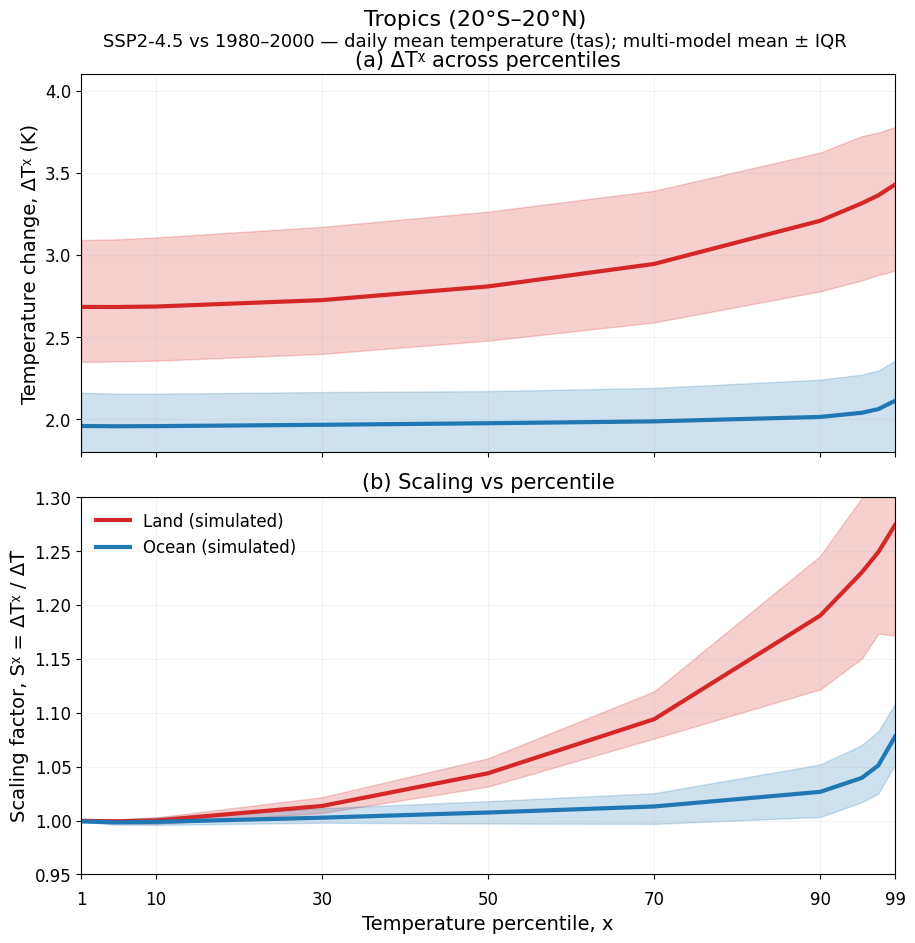

Saved: /content/drive/MyDrive/climate_work/historical_output/fig2_ssp245_tropics/Fig2_vertical_SHAREDX_LINEAR_tas.png
Models included: 22


In [ ]:
# ==== Byrne Fig-2 style for TAS: vertical, shared x, LINEAR percentile axis ====
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, ScalarFormatter

# ---------- paths (tas) ----------
WORKDIR = "/content/drive/MyDrive/climate_work"
OUTCSV  = f"{WORKDIR}/historical_output/fig2_ssp245_tropics/Fig2_curves_per_model.csv"  # tas CSV from your compute step
VAR     = "tas"

# ---------- load + aggregate ----------
df = pd.read_csv(OUTCSV)
OUTDIR = os.path.dirname(OUTCSV)

def _agg(data, cols):
    g = data.groupby("percentile")[cols]
    return g.mean(), g.quantile(0.25), g.quantile(0.75)

mean_dT, q25_dT, q75_dT = _agg(df, ["dTx_land","dTx_ocean"])
mean_S , q25_S , q75_S  = _agg(df, ["Sx_land","Sx_ocean"])
x = mean_dT.index.values

# ---------- style ----------
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 15, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "savefig.dpi": 300
})

# Linear x-axis with Byrne-like ticks
major_ticks = [1, 10, 30, 50, 70, 90, 99]
major_loc   = FixedLocator(major_ticks)
major_fmt   = ScalarFormatter(useMathText=False)

def style_xaxis_linear(ax):
    ax.set_xlim(1, 99)                        # tight to 99; use (1,100) for a hair more room
    ax.xaxis.set_major_locator(major_loc)
    ax.xaxis.set_major_formatter(major_fmt)
    ax.margins(x=0)
    ax.tick_params(axis="x", pad=8)

# ---------- figure: vertical stack, shared x ----------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10.5, 10.0), sharex=True, gridspec_kw={"hspace": 0.12}
)

# (a) ΔT^x across percentiles
ax1.plot(x, mean_dT["dTx_land"],  color="tab:red",  lw=3, label="Land (simulated)")
ax1.plot(x, mean_dT["dTx_ocean"], color="tab:blue", lw=3, label="Ocean (simulated)")
ax1.fill_between(x, q25_dT["dTx_land"],  q75_dT["dTx_land"],  color="tab:red",  alpha=0.22)
ax1.fill_between(x, q25_dT["dTx_ocean"], q75_dT["dTx_ocean"], color="tab:blue", alpha=0.22)
ax1.set_ylim(1.8, 4.1)                        # tas
ax1.set_ylabel("Temperature change, ΔTᵡ (K)")
ax1.set_title("(a) ΔTᵡ across percentiles", pad=6)
ax1.grid(alpha=0.15)
ax1.tick_params(labelbottom=False)

# (b) Scaling factor S^x
ax2.plot(x, mean_S["Sx_land"],  color="tab:red",  lw=3, label="Land (simulated)")
ax2.plot(x, mean_S["Sx_ocean"], color="tab:blue", lw=3, label="Ocean (simulated)")
ax2.fill_between(x, q25_S["Sx_land"],  q75_S["Sx_land"],  color="tab:red",  alpha=0.22)
ax2.fill_between(x, q25_S["Sx_ocean"], q75_S["Sx_ocean"], color="tab:blue", alpha=0.22)
ax2.set_ylim(0.95, 1.30)
ax2.yaxis.tick_left(); ax2.yaxis.set_label_position("left")
ax2.set_ylabel("Scaling factor, Sᵡ = ΔTᵡ / ΔT̄")
ax2.set_title("(b) Scaling vs percentile", pad=6)
ax2.grid(alpha=0.15)
ax2.legend(loc="upper left", frameon=False)

# shared linear x-axis
style_xaxis_linear(ax2)
ax2.set_xlabel("Temperature percentile, x")

# Titles with spacing
main_title = "Tropics (20°S–20°N)"
sub_title  = "SSP2-4.5 vs 1980–2000 — daily mean temperature (tas); multi-model mean ± IQR"
fig.subplots_adjust(top=0.90, bottom=0.10)
fig.suptitle(main_title, y=0.965, fontsize=16)
fig.text(0.5, 0.942, sub_title, ha='center', va='top', fontsize=13)

# Save
save_path = os.path.join(OUTDIR, f"Fig2_vertical_SHAREDX_LINEAR_{VAR}.png")
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print("Saved:", save_path)
print("Models included:", df['model'].nunique())


In [ ]:
# ============================ SETUP (Colab) ============================
# If it's a fresh runtime, uncomment the installs ↓ once, then re-run the cell.
# !pip -q install xarray pandas regionmask gcsfs zarr fsspec tqdm > /dev/null

import os, numpy as np, pandas as pd, xarray as xr
from tqdm.auto import tqdm
import regionmask

# ---------------- Paths (Google Drive) ----------------
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
WORKDIR = "/content/drive/MyDrive/climate_work"
OUTDIR  = f"{WORKDIR}/historical_output/fig2_ssp245_tropics_tasmax"
os.makedirs(OUTDIR, exist_ok=True)
OUTCSV  = os.path.join(OUTDIR, "Fig2_curves_per_model_tasmax.csv")

# ============================ CONFIG ============================
VAR = "tasmax"                          # daily maximum temperature
HIST = ("1980-01-01","2000-12-31")      # Byrne reference period
FUT  = ("2080-01-01","2100-12-31")      # SSP2-4.5 late-century
LAT_BAND = (-20, 20)                    # tropics
PCTS = np.array([1, 10, 30, 50, 70, 90, 95, 97, 99], dtype=int)

ALLOWED = sorted({
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
})

# ======================= DATA ACCESS (Pangeo) =======================
CMIP6_CSV = "https://storage.googleapis.com/cmip6/pangeo-cmip6.csv"
_cat = None
def catalog():
    global _cat
    if _cat is None:
        _cat = pd.read_csv(CMIP6_CSV)
    return _cat

def normalize_latlon(obj):
    if "latitude" in obj.coords: obj = obj.rename({"latitude":"lat"})
    if "longitude" in obj.coords: obj = obj.rename({"longitude":"lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180).sortby("lon")
    if "lat" in obj.coords and obj.lat.size > 1 and float(obj.lat[0]) > float(obj.lat[-1]):
        obj = obj.sortby("lat")
    return obj

def open_var(model, experiment, var):
    df = catalog()
    sub = df[(df.source_id==model) & (df.experiment_id==experiment) &
             (df.table_id=="day") & (df.variable_id==var)]
    if sub.empty:
        raise RuntimeError(f"No {experiment}/day {var} for {model}")
    # Prefer first member/grid; adjust here if you want to pin member_id/grid_label
    zurl = sub.sort_values(["member_id","grid_label"]).iloc[0].zstore
    da = xr.open_zarr(zurl, consolidated=True, storage_options={"token":"anon"}, chunks={})[var]
    da = normalize_latlon(da)
    units = (da.attrs.get("units","") or "").lower()
    if units in ("k","kelvin") or (float(da.max())>200 and float(da.min())>150):
        da = da - 273.15
        da.attrs["units"] = "degree_Celsius"
    return da

# ========================== CORE CALCS ==========================
# Pool over time×lon *per latitude*, compute exceedance means at percentile thresholds
def zonal_mean_exceedances(da_hist, da_fut, mask_bool, pcts=PCTS):
    H = da_hist.where(mask_bool)
    F = da_fut.where(mask_bool)

    Hs = H.stack(sample=("time","lon")).transpose("lat","sample").values  # (lat, sample)
    Fs = F.stack(sample=("time","lon")).transpose("lat","sample").values

    def exceed_means(arr):
        # arr: (lat, sample)
        thr = np.nanpercentile(arr, pcts, axis=1)           # (len(pcts), lat)
        out = []
        for i in range(len(pcts)):
            m = np.nanmean(np.where(arr >= thr[i, :][:,None], arr, np.nan), axis=1)
            out.append(m)                                   # (lat,)
        return np.stack(out, axis=0)                        # (p, lat)

    hist_means = exceed_means(Hs)
    fut_means  = exceed_means(Fs)
    return fut_means - hist_means                           # ΔT^x(lat): (p, lat)

def mean_day_delta(da_hist, da_fut, mask_bool):
    Hm = da_hist.where(mask_bool).mean(("time","lon"), skipna=True).values  # (lat,)
    Fm = da_fut .where(mask_bool).mean(("time","lon"), skipna=True).values
    return Fm - Hm

def tropical_average(lat_vals, field_plat):
    w = np.cos(np.deg2rad(lat_vals))
    w = w / np.nansum(w)
    return np.nansum(field_plat * w[None, :], axis=1)       # (p,)

def weighted_lat_mean(lat_vals, lat_field):
    w = np.cos(np.deg2rad(lat_vals))
    return np.nansum(lat_field * w) / np.nansum(w)          # scalar

# ============================ RUN ============================
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
rows = []

for model in tqdm(ALLOWED, desc="Compute tasmax curves"):
    try:
        H = open_var(model, "historical", VAR).sel(time=slice(*HIST)).sel(lat=slice(*LAT_BAND))
        F = open_var(model, "ssp245",    VAR).sel(time=slice(*FUT )).sel(lat=slice(*LAT_BAND))
        H = normalize_latlon(H); F = normalize_latlon(F)

        # land/ocean masks at model grid
        m = land.mask(H["lon"], H["lat"])
        land_mask  = m.notnull()
        ocean_mask = m.isnull()

        # ΔT^x (p, lat) for land & ocean
        dTx_land_lat  = zonal_mean_exceedances(H, F, land_mask)
        dTx_ocean_lat = zonal_mean_exceedances(H, F, ocean_mask)

        # mean-day warming per latitude (ΔT̄(lat)) and tropical averages
        dT_land_lat  = mean_day_delta(H, F, land_mask)
        dT_ocean_lat = mean_day_delta(H, F, ocean_mask)

        lat_vals = H["lat"].values
        dTx_land  = tropical_average(lat_vals, dTx_land_lat)      # (p,)
        dTx_ocean = tropical_average(lat_vals, dTx_ocean_lat)     # (p,)
        dT_land   = weighted_lat_mean(lat_vals, dT_land_lat)      # scalar
        dT_ocean  = weighted_lat_mean(lat_vals, dT_ocean_lat)     # scalar

        Sx_land  = dTx_land  / dT_land
        Sx_ocean = dTx_ocean / dT_ocean

        for ip, x in enumerate(PCTS):
            rows.append({
                "model": model, "percentile": int(x),
                "dTx_land": dTx_land[ip], "dTx_ocean": dTx_ocean[ip],
                "Sx_land": Sx_land[ip],   "Sx_ocean": Sx_ocean[ip],
                "dT_land": dT_land,       "dT_ocean": dT_ocean
            })

        # save partial progress to guard against runtime disconnects
        pd.DataFrame(rows).to_csv(OUTCSV.replace(".csv","_partial.csv"), index=False)

        # free memory a bit
        import gc
        del H, F, dTx_land_lat, dTx_ocean_lat
        gc.collect()

    except Exception as e:
        print(f"[skip] {model}: {e}")

df = pd.DataFrame(rows)
df.to_csv(OUTCSV, index=False)
print("\nSaved tasmax curves CSV:", OUTCSV)
print("Models included:", df["model"].nunique())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Compute tasmax curves:   0%|          | 0/25 [00:00<?, ?it/s]

[skip] ACCESS-ESM1-5: No ssp245/day tasmax for ACCESS-ESM1-5
[skip] CMCC-CM2-SR5: No historical/day tasmax for CMCC-CM2-SR5
[skip] CNRM-CM6-1-HR: No ssp245/day tasmax for CNRM-CM6-1-HR
[skip] HadGEM3-GC31-LL: No historical/day tasmax for HadGEM3-GC31-LL
[skip] IITM-ESM: No historical/day tasmax for IITM-ESM
[skip] UKESM1-0-LL: No historical/day tasmax for UKESM1-0-LL

Saved tasmax curves CSV: /content/drive/MyDrive/climate_work/historical_output/fig2_ssp245_tropics_tasmax/Fig2_curves_per_model_tasmax.csv
Models included: 19


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


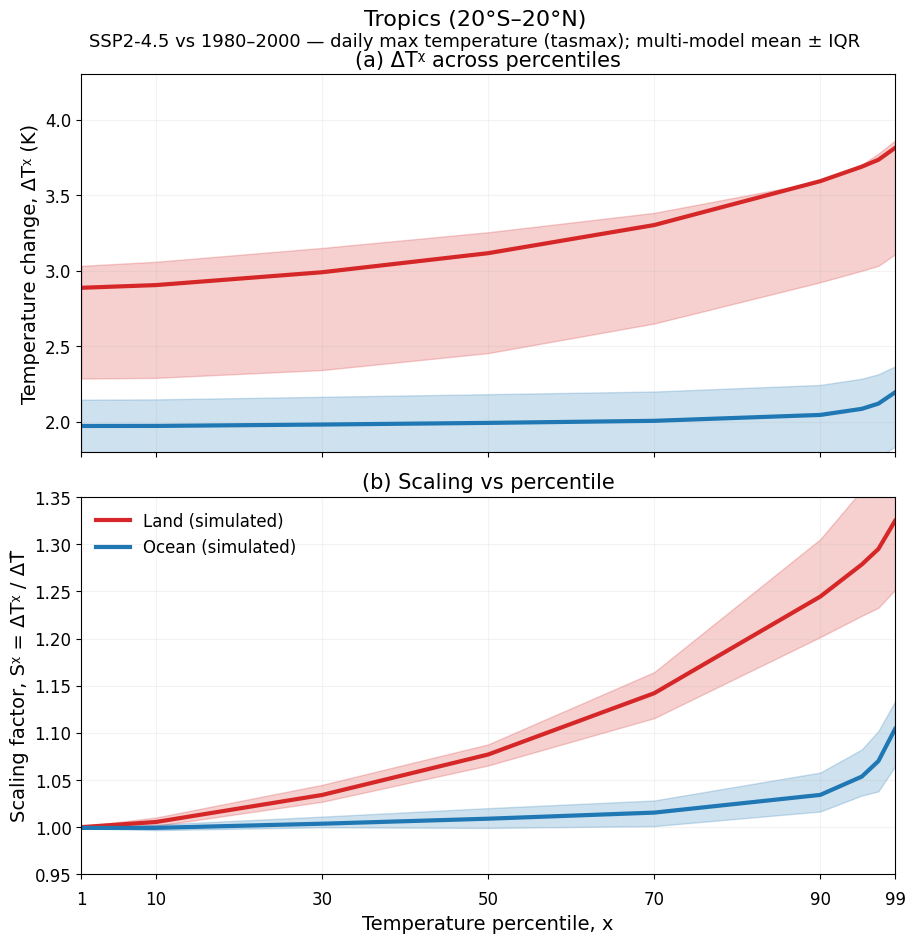

Saved: /content/drive/MyDrive/climate_work/historical_output/fig2_ssp245_tropics_tasmax/Fig2_vertical_SHAREDX_LINEAR_tasmax.png
Models included: 19


In [ ]:
# ==== Byrne Fig-2 style for TASMAX: vertical, shared x, LINEAR percentile axis ====
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, ScalarFormatter

# ---------- paths (tasmax) ----------
WORKDIR = "/content/drive/MyDrive/climate_work"
OUTCSV  = f"{WORKDIR}/historical_output/fig2_ssp245_tropics_tasmax/Fig2_curves_per_model_tasmax.csv"
VAR     = "tasmax"

# ---------- load + aggregate ----------
df = pd.read_csv(OUTCSV)               # includes all models that succeeded in compute step
OUTDIR = os.path.dirname(OUTCSV)

def _agg(data, cols):
    g = data.groupby("percentile")[cols]
    return g.mean(), g.quantile(0.25), g.quantile(0.75)

mean_dT, q25_dT, q75_dT = _agg(df, ["dTx_land","dTx_ocean"])
mean_S , q25_S , q75_S  = _agg(df, ["Sx_land","Sx_ocean"])
x = mean_dT.index.values

# ---------- style ----------
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 15, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "savefig.dpi": 300
})

# Linear axis, fixed major ticks (Byrne-like)
major_ticks = [1, 10, 30, 50, 70, 90, 99]
major_loc   = FixedLocator(major_ticks)
major_fmt   = ScalarFormatter(useMathText=False)

def style_xaxis_linear(ax):
    ax.set_xlim(1, 99)
    ax.xaxis.set_major_locator(major_loc)
    ax.xaxis.set_major_formatter(major_fmt)
    ax.margins(x=0)                 # no extra whitespace
    ax.tick_params(axis="x", pad=8)

# ---------- figure: vertical stack, shared x ----------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10.5, 10.0), sharex=True, gridspec_kw={"hspace": 0.12}
)

# (a) ΔT^x (top)
ax1.plot(x, mean_dT["dTx_land"],  color="tab:red",  lw=3, label="Land (simulated)")
ax1.plot(x, mean_dT["dTx_ocean"], color="tab:blue", lw=3, label="Ocean (simulated)")
ax1.fill_between(x, q25_dT["dTx_land"],  q75_dT["dTx_land"],  color="tab:red",  alpha=0.22)
ax1.fill_between(x, q25_dT["dTx_ocean"], q75_dT["dTx_ocean"], color="tab:blue", alpha=0.22)
ax1.set_ylim(1.8, 4.3)                       # a touch higher for tasmax extremes
ax1.set_ylabel("Temperature change, ΔTᵡ (K)")
ax1.set_title("(a) ΔTᵡ across percentiles", pad=6)
ax1.grid(alpha=0.15)
ax1.tick_params(labelbottom=False)

# (b) Sx (bottom)
ax2.plot(x, mean_S["Sx_land"],  color="tab:red",  lw=3, label="Land (simulated)")
ax2.plot(x, mean_S["Sx_ocean"], color="tab:blue", lw=3, label="Ocean (simulated)")
ax2.fill_between(x, q25_S["Sx_land"],  q75_S["Sx_land"],  color="tab:red",  alpha=0.22)
ax2.fill_between(x, q25_S["Sx_ocean"], q75_S["Sx_ocean"], color="tab:blue", alpha=0.22)
ax2.set_ylim(0.95, 1.35)
ax2.yaxis.tick_left(); ax2.yaxis.set_label_position("left")
ax2.set_ylabel("Scaling factor, Sᵡ = ΔTᵡ / ΔT̄")
ax2.set_title("(b) Scaling vs percentile", pad=6)
ax2.grid(alpha=0.15)
ax2.legend(loc="upper left", frameon=False)

# shared linear x-axis (Byrne-like)
style_xaxis_linear(ax2)
ax2.set_xlabel("Temperature percentile, x")

# Titles with spacing
main_title = "Tropics (20°S–20°N)"
sub_title  = "SSP2-4.5 vs 1980–2000 — daily max temperature (tasmax); multi-model mean ± IQR"
fig.subplots_adjust(top=0.90, bottom=0.10)
fig.suptitle(main_title, y=0.965, fontsize=16)
fig.text(0.5, 0.942, sub_title, ha='center', va='top', fontsize=13)

# Save
save_path = os.path.join(OUTDIR, f"Fig2_vertical_SHAREDX_LINEAR_{VAR}.png")
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print("Saved:", save_path)
print("Models included:", df['model'].nunique())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using 17 models with day tasmax + tas (Amon or day fallback) (hist+ssp245):
['ACCESS-CM2', 'AWI-CM-1-1-MR', 'CAMS-CSM1-0', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'GFDL-CM4', 'GFDL-ESM4', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'NorESM2-MM']
Predictor matches Fig 2: tropical land mean tas anomaly rel. (2005, 2014).
Record definition: EXCEEDS fixed historical record (max over (1980, 2014)).
Fit window: (2015, 2100) | pooled ridge alpha=0.2


/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cf

[ok data] ACCESS-CM2   years= 86  exceed=12  nonexceed= 74  T*_hist=54.99°C


/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cf

[ok data] AWI-CM-1-1-MR years= 86  exceed=52  nonexceed= 34  T*_hist=56.59°C


...

[ok data] INM-CM5-0    years= 86  exceed=55  nonexceed= 31  T*_hist=52.89°C


/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cf

[ok data] IPSL-CM6A-LR years= 86  exceed= 2  nonexceed= 84  T*_hist=54.67°C


/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-1710516404.py:180: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cf

[ok data] NorESM2-MM   years= 86  exceed=31  nonexceed= 55  T*_hist=53.23°C

Saved fixed-threshold record levels: /content/drive/MyDrive/cmip6_extreme_hot_days/recordprob_fig2style_fixedThreshold/fixed_record_levels_hist1980-2014.csv

Pooled MMM ridge-logit: OR=1.35 per °C_TL  (+35% odds/°C_TL)
Saved OR table: /content/drive/MyDrive/cmip6_extreme_hot_days/recordprob_fig2style_fixedThreshold/logit_OR_summary_fixedThreshold_fit2015-2100_alpha0.2.csv
Spaghetti curves: 15 models (min exceedances 3)

Expected # exceedance years (sum of annual probabilities) 2026–2100:
count    16.000000
mean     42.011442
std       2.003902
min      39.129208
10%      39.520129
50%      41.884389
90%      44.755154
max      46.034615
Name: E_exceed, dtype: float64
MMM expected exceedance-years: 42.01


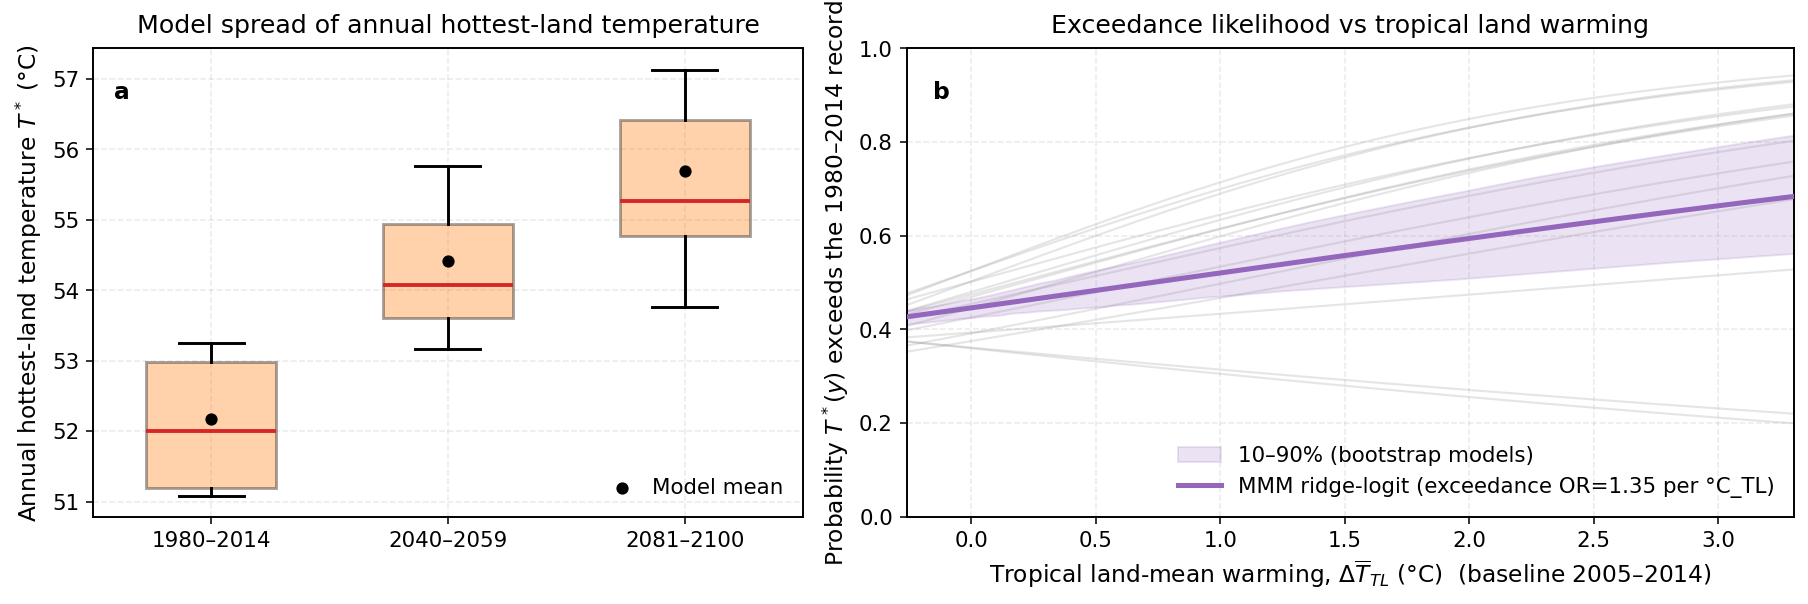

Saved: /content/drive/MyDrive/cmip6_extreme_hot_days/recordprob_fig2style_fixedThreshold/fig_recordprob_fixedThreshold_twoPanel_fig2style.png and /content/drive/MyDrive/cmip6_extreme_hot_days/recordprob_fig2style_fixedThreshold/fig_recordprob_fixedThreshold_twoPanel_fig2style.svg
Done.


In [ ]:
# ============================================================
# FIXED-THRESHOLD "RECORD EXCEEDANCE" PROBABILITY FIGURE (ROBUST TIME)
#
# Panel (a) boxplot: annual hottest-land temperature T*(y) by period across models
# Panel (b) logistic GLM: P(T*(y) > T*_record_hist) vs tropical land warming ΔT_TL(y)
#
# KEY CONSISTENCY CHOICES:
# - Predictor matches Fig 2: ΔT_TL relative to 2005–2014 (historical baseline)
# - T*(y): annual max of daily tasmax global land within LAT_BAND (default -45..45)
# - Event = FIXED historical-record exceedance:
#       record=1 if T*(y) > max_{1980–2014} T*(y)
#   (NOT running “new record” / ratcheting)
#
# ROBUSTNESS UPGRADES:
# - Force decoded times: open_zarr(decode_times=True, use_cftime=True)
# - Avoid fragile groupby("time.year"): create explicit year coord via years_from_time()
# - Avoid resample("1MS") in tas fallback path: annualize directly via explicit year coord
# ============================================================

# !pip -q install xarray pandas regionmask gcsfs zarr fsspec statsmodels > /dev/null

from google.colab import drive
drive.mount("/content/drive")

import os, gc
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import regionmask
import statsmodels.api as sm

# ============================ USER SETTINGS ============================
OUTDIR = "/content/drive/MyDrive/cmip6_extreme_hot_days/recordprob_fig2style_fixedThreshold"
os.makedirs(OUTDIR, exist_ok=True)

# Predictor settings (match Fig 2)
REF_DTBAR = (2005, 2014)     # baseline for ΔT_TL anomaly
TROP_BAND = (-30, 30)        # tropical band for TL predictor

# Record metric settings
VAR_TASMAX       = "tasmax"
LAT_BAND         = (-45, 45) # land region for T* metric
WARM_SEASON_ONLY = False     # keep False unless you want a warm-season definition

# Record threshold window and fit/eval windows
HIST_RECORD_WINDOW = (1980, 2014)  # fixed record level = max over this window
FIT_WINDOW         = (2015, 2100)  # years used to fit GLM
EVAL_WINDOW        = (2026, 2100)  # expected # exceedance years summed here

# Model selection
ALLOWED = {
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-MM","UKESM1-0-LL"
}
EXCLUDE = {"NorESM2-LM", "TaiESM1"}

# Plot periods for panel (a)
PERIODS = [
    ("1980–2014", 1980, 2014),
    ("2040–2059", 2040, 2059),
    ("2081–2100", 2081, 2100),
]

# Fit stability controls
ALPHA_RIDGE_POOLED = 0.2
ALPHA_RIDGE_SPAGH  = 0.2
MIN_YEARS_FIT      = 25
MIN_RECORDS_SPAGH  = 3
MIN_NONREC_SPAGH   = 10

# Colors to match Fig 2 vibe
C_ORANGE = "tab:orange"
C_RED    = "tab:red"
C_PURPLE = "tab:purple"

# Figure style (similar to Fig 2)
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.5,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# ============================ CMIP6 CATALOG ============================
CMIP6_CSV = "https://storage.googleapis.com/cmip6/pangeo-cmip6.csv"
_cat = None

def catalog():
    global _cat
    if _cat is None:
        _cat = pd.read_csv(CMIP6_CSV)
    return _cat

# ============================ TIME HELPERS (robust) ============================
def years_from_time(time_coord):
    # xarray datetime accessor
    try:
        return time_coord.dt.year.values
    except Exception:
        pass
    # DatetimeIndex / CFTimeIndex
    try:
        return time_coord.to_index().year
    except Exception:
        pass
    # last resort
    try:
        return pd.to_datetime(np.asarray(time_coord.values)).year
    except Exception as e:
        raise RuntimeError(f"Could not extract years from time coord: {type(time_coord.values)}") from e

def months_from_time(time_coord):
    try:
        return time_coord.dt.month.values
    except Exception:
        pass
    try:
        return time_coord.to_index().month
    except Exception:
        pass
    try:
        return pd.to_datetime(np.asarray(time_coord.values)).month
    except Exception as e:
        raise RuntimeError(f"Could not extract months from time coord: {type(time_coord.values)}") from e

# ============================ DATA OPEN HELPERS ============================
def normalize_latlon(obj):
    if "latitude" in obj.coords:
        obj = obj.rename({"latitude": "lat"})
    if "longitude" in obj.coords:
        obj = obj.rename({"longitude": "lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180).sortby("lon")
    if "lat" in obj.coords and obj.lat.size > 1 and float(obj.lat[0]) > float(obj.lat[-1]):
        obj = obj.sortby("lat")
    return obj

def looks_like_kelvin(da):
    try:
        mx = float(da.max())
        mn = float(da.min())
        return (mx > 200) and (mn > 150)
    except Exception:
        v = da.isel({da.dims[0]: 0}).values
        return np.nanmax(v) > 200

def to_celsius(da):
    units = (da.attrs.get("units", "") or "").lower()
    if units in ["k", "kelvin"] or looks_like_kelvin(da):
        da = da - 273.15
        da.attrs["units"] = "degree_Celsius"
    return da

def pick_zstore(model, experiment, table_id, variable_id):
    df = catalog()
    sub = df[
        (df.source_id == model)
        & (df.experiment_id == experiment)
        & (df.table_id == table_id)
        & (df.variable_id == variable_id)
    ]
    if sub.empty:
        return None
    # deterministic: first member/grid
    return sub.sort_values(["member_id", "grid_label"]).iloc[0].zstore

def open_zarr_da(zurl, var):
    ds = xr.open_zarr(
        zurl,
        consolidated=True,
        storage_options={"token": "anon"},
        chunks={},
        decode_times=True,
        use_cftime=True,
    )
    da = normalize_latlon(ds[var])
    if "time" in da.dims:
        da = da.sortby("time")
    return da

def open_daily_tasmax(model, experiment):
    zurl = pick_zstore(model, experiment, "day", VAR_TASMAX)
    if zurl is None:
        raise RuntimeError(f"No day/{VAR_TASMAX} for {model} {experiment}")
    return to_celsius(open_zarr_da(zurl, VAR_TASMAX))

def open_amon_tas_or_fallback(model, experiment):
    """
    Prefer Amon tas; fallback to daily tas (annualized later robustly).
    """
    zurl = pick_zstore(model, experiment, "Amon", "tas")
    if zurl is not None:
        return to_celsius(open_zarr_da(zurl, "tas"))

    zurl2 = pick_zstore(model, experiment, "day", "tas")
    if zurl2 is None:
        raise RuntimeError(f"No Amon tas and no day tas for {model} {experiment}")
    return to_celsius(open_zarr_da(zurl2, "tas"))

# ============================ MASKS & WEIGHTS (cached land mask) ============================
land_poly = regionmask.defined_regions.natural_earth_v5_0_0.land_110
_landmask_cache = {}

def area_weights(lat):
    w = np.cos(np.deg2rad(lat))
    return xr.DataArray(w / w.sum(), coords={"lat": lat}, dims=("lat",))

def land_mask_bool(lon, lat):
    key = (int(lat.size), int(lon.size),
           float(lat.values[0]), float(lat.values[-1]),
           float(lon.values[0]), float(lon.values[-1]))
    if key in _landmask_cache:
        return _landmask_cache[key]
    m = land_poly.mask(lon, lat).notnull()
    _landmask_cache[key] = m
    return m

def apply_land_and_band(da, lat_band):
    da = da.sel(lat=slice(*lat_band))
    m = land_mask_bool(da["lon"], da["lat"])
    return da.where(m)

def select_warm_season(da):
    if not WARM_SEASON_ONLY:
        return da
    months = months_from_time(da["time"])
    mm = xr.DataArray(months, coords={"time": da["time"]}, dims=("time",))

    da_nh = da.sel(lat=slice(max(0.0, LAT_BAND[0]), LAT_BAND[1]))
    if da_nh.lat.size > 0:
        da_nh = da_nh.sel(time=mm.isin([6, 7, 8]))

    da_sh = da.sel(lat=slice(LAT_BAND[0], min(0.0, LAT_BAND[1])))
    if da_sh.lat.size > 0:
        da_sh = da_sh.sel(time=mm.isin([12, 1, 2]))

    if da_nh.lat.size > 0 and da_sh.lat.size > 0:
        return xr.concat([da_sh, da_nh], dim="lat")
    elif da_nh.lat.size > 0:
        return da_nh
    else:
        return da_sh

# ============================ ΔT_TL: annual tropical-land mean tas anomaly ============================
def annual_TL_abs(model, experiment):
    """
    Annual tropical-land mean tas (absolute, °C).
    Robust annualization via explicit year coord (no time.year or resample).
    """
    tas = open_amon_tas_or_fallback(model, experiment)

    if "time" not in tas.dims:
        if "year" in tas.coords:
            df = pd.DataFrame({"year": tas["year"].values.astype(int),
                               "TL": np.asarray(tas.values, dtype=float)})
            return df.dropna().sort_values("year")
        raise RuntimeError(f"{model} {experiment}: tas has no usable time/year dimension")

    tas = tas.sortby("time")
    tas_tl = apply_land_and_band(tas, TROP_BAND)
    w = area_weights(tas_tl.lat)
    tl = tas_tl.weighted(w).mean(("lat", "lon"), skipna=True)

    yrs = years_from_time(tl["time"])
    tl = tl.assign_coords(year=("time", yrs))
    ann = tl.groupby("year").mean("time").compute()

    df = pd.DataFrame({"year": ann["year"].values.astype(int),
                       "TL": np.asarray(ann.values, dtype=float)})
    return df.dropna().sort_values("year")

def annual_dT_TL_histbaseline(model, ref_years=REF_DTBAR):
    Dh = annual_TL_abs(model, "historical")
    Ds = annual_TL_abs(model, "ssp245")
    Dall = pd.concat([Dh, Ds], axis=0).drop_duplicates("year").sort_values("year")

    refmask = (Dall["year"] >= ref_years[0]) & (Dall["year"] <= ref_years[1])
    if refmask.sum() == 0:
        raise RuntimeError(f"{model}: baseline {ref_years} not present in HIST+SSP TL series")

    ref = float(np.nanmean(Dall.loc[refmask, "TL"].values))
    Dall["dT_TL"] = Dall["TL"] - ref
    return Dall[["year", "dT_TL"]].dropna().sort_values("year")

# ============================ Annual hottest-land temperature T*(y) ============================
def annual_Tstar(model, experiment, time_chunk=365):
    """
    T*(y): annual max of daily global-land max tasmax within LAT_BAND and land mask.
    Robust annualization via explicit year coord.
    """
    da = open_daily_tasmax(model, experiment).chunk({"time": time_chunk})
    da = apply_land_and_band(da, LAT_BAND)
    da = select_warm_season(da)

    daily_max = da.max(("lat", "lon"), skipna=True)

    yrs = years_from_time(daily_max["time"])
    daily_max = daily_max.assign_coords(year=("time", yrs))

    Tstar = daily_max.groupby("year").max("time").compute()

    df = pd.DataFrame({"year": Tstar["year"].values.astype(int),
                       "Tstar": np.asarray(Tstar.values, dtype=float)})
    return df.dropna().sort_values("year")

# ============================ Fixed-threshold record exceedance ============================
def add_fixed_record_flag(df, init_window=HIST_RECORD_WINDOW, start_year=FIT_WINDOW[0]):
    """
    record_level = max Tstar over init_window (e.g., 1980–2014)
    record(y)=1 if year>=start_year and Tstar(y) > record_level.
    """
    df = df.sort_values("year").reset_index(drop=True)
    y0, y1 = init_window
    m0 = (df["year"] >= y0) & (df["year"] <= y1)
    if m0.sum() == 0:
        raise RuntimeError(f"no years in HIST_RECORD_WINDOW {init_window} after merge")

    record_level = float(df.loc[m0, "Tstar"].max())

    rec = []
    for y, t in zip(df["year"].values, df["Tstar"].values):
        if y < start_year:
            rec.append(0)
        else:
            rec.append(int(float(t) > record_level))

    df["record"] = rec
    df.attrs["fixed_record_level"] = record_level
    return df

def build_model_df(model):
    Th = annual_Tstar(model, "historical")
    Tf = annual_Tstar(model, "ssp245")
    Tdf = pd.concat([Th, Tf], axis=0).drop_duplicates("year").sort_values("year")

    Ddf = annual_dT_TL_histbaseline(model, ref_years=REF_DTBAR)

    df = pd.merge(Tdf, Ddf, on="year", how="inner").sort_values("year")
    df = add_fixed_record_flag(df, init_window=HIST_RECORD_WINDOW, start_year=FIT_WINDOW[0])

    df_fit = df[(df["year"] >= FIT_WINDOW[0]) & (df["year"] <= FIT_WINDOW[1])].copy()
    if df_fit.shape[0] < MIN_YEARS_FIT:
        raise RuntimeError(f"Too few years in fit window {FIT_WINDOW}: n={df_fit.shape[0]}")
    return df, df_fit

# ============================ Ridge logistic fit helpers ============================
def ridge_logit_fit(x, y, alpha=0.2):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    X = sm.add_constant(x, has_constant="add")
    model = sm.GLM(y, X, family=sm.families.Binomial())
    res = model.fit_regularized(alpha=alpha, L1_wt=0.0, maxiter=2000)
    return np.asarray(res.params, dtype=float)

def logit_predict(params, xgrid):
    xgrid = np.asarray(xgrid, dtype=float)
    Xg = sm.add_constant(xgrid, has_constant="add")
    eta = Xg @ params
    return 1.0 / (1.0 + np.exp(-eta))

# ============================ MODEL LIST ============================
def list_models_with_tasmax_and_tas_hist_ssp245():
    df = catalog()

    have_tasmax_day = df[(df.table_id == "day") & (df.variable_id == "tasmax")]
    hist_tmax = set(have_tasmax_day[have_tasmax_day.experiment_id == "historical"].source_id.unique())
    ssp_tmax  = set(have_tasmax_day[have_tasmax_day.experiment_id == "ssp245"].source_id.unique())
    ok_tmax = hist_tmax & ssp_tmax

    have_tas_amon = df[(df.table_id == "Amon") & (df.variable_id == "tas")]
    hist_tasA = set(have_tas_amon[have_tas_amon.experiment_id == "historical"].source_id.unique())
    ssp_tasA  = set(have_tas_amon[have_tas_amon.experiment_id == "ssp245"].source_id.unique())

    have_tas_day = df[(df.table_id == "day") & (df.variable_id == "tas")]
    hist_tasD = set(have_tas_day[have_tas_day.experiment_id == "historical"].source_id.unique())
    ssp_tasD  = set(have_tas_day[have_tas_day.experiment_id == "ssp245"].source_id.unique())

    ok_tas = (hist_tasA | hist_tasD) & (ssp_tasA | ssp_tasD)

    models = sorted(((ok_tmax & ok_tas) & set(ALLOWED)) - set(EXCLUDE))
    return models

# ============================ MAIN: build all model data ============================
MODELS_ALL = list_models_with_tasmax_and_tas_hist_ssp245()

print(f"Using {len(MODELS_ALL)} models with day tasmax + tas (Amon or day fallback) (hist+ssp245):")
print(MODELS_ALL)
print(f"Predictor matches Fig 2: tropical land mean tas anomaly rel. {REF_DTBAR}.")
print(f"Record definition: EXCEEDS fixed historical record (max over {HIST_RECORD_WINDOW}).")
print(f"Fit window: {FIT_WINDOW} | pooled ridge alpha={ALPHA_RIDGE_POOLED}")

per_model = {}
rows = []
record_levels = {}

for md in MODELS_ALL:
    try:
        df, df_fit = build_model_df(md)
        per_model[md] = (df, df_fit)
        record_levels[md] = float(df.attrs.get("fixed_record_level", np.nan))

        tmp = df_fit.copy()
        tmp["model"] = md
        rows.append(tmp)

        n1 = int(df_fit["record"].sum())
        n0 = int((df_fit["record"] == 0).sum())
        print(f"[ok data] {md:12s} years={df_fit.shape[0]:3d}  exceed={n1:2d}  nonexceed={n0:3d}  "
              f"T*_hist={record_levels[md]:.2f}°C")
    except Exception as e:
        print(f"[skip data] {md}: {e}")

if len(rows) == 0:
    raise RuntimeError("No models produced usable data. Check earlier skip reasons.")

pool = pd.concat(rows, axis=0).reset_index(drop=True)

# Save per-model fixed record thresholds (useful for SI)
levels_df = pd.DataFrame({
    "model": list(record_levels.keys()),
    "Tstar_record_hist_C": list(record_levels.values()),
}).sort_values("Tstar_record_hist_C")
levels_csv = os.path.join(OUTDIR, f"fixed_record_levels_hist{HIST_RECORD_WINDOW[0]}-{HIST_RECORD_WINDOW[1]}.csv")
levels_df.to_csv(levels_csv, index=False)
print(f"\nSaved fixed-threshold record levels: {levels_csv}")

# ============================ (A) Panel values: T* by period ============================
def collect_period_Tstar(per_model_dict, periods=PERIODS):
    out = {lab: [] for (lab, _, _) in periods}
    for _md, (df, _df_fit) in per_model_dict.items():
        for lab, y0, y1 in periods:
            m = (df["year"] >= y0) & (df["year"] <= y1)
            if m.sum() > 0:
                out[lab].append(float(df.loc[m, "Tstar"].mean()))
    return {k: np.array(v, dtype=float) for k, v in out.items()}

period_vals = collect_period_Tstar(per_model)

# ============================ (B) Logistic model: pooled MMM + optional spaghetti ============================
x_all = pool["dT_TL"].values
y_all = pool["record"].values

params_pool = ridge_logit_fit(x_all, y_all, alpha=ALPHA_RIDGE_POOLED)
OR_pool = float(np.exp(params_pool[1]))
print(f"\nPooled MMM ridge-logit: OR={OR_pool:.2f} per °C_TL  ({(OR_pool-1)*100:+.0f}% odds/°C_TL)")

# x-grid over central model ranges
xmins, xmaxs = [], []
for md, (_df, df_fit) in per_model.items():
    xmins.append(df_fit["dT_TL"].min())
    xmaxs.append(df_fit["dT_TL"].max())
x_lo = float(np.nanpercentile(xmins, 20))
x_hi = float(np.nanpercentile(xmaxs, 80))
xg = np.linspace(x_lo, x_hi, 300)

p_mmm = logit_predict(params_pool, xg)

def bootstrap_band(per_model_dict, xg, B=200, alpha=ALPHA_RIDGE_POOLED, qlo=10, qhi=90, seed=7):
    rng = np.random.default_rng(seed)
    models = list(per_model_dict.keys())
    preds = []
    for _ in range(B):
        samp = rng.choice(models, size=len(models), replace=True)
        parts = []
        for md in samp:
            df_fit = per_model_dict[md][1].copy()
            df_fit["model"] = md
            parts.append(df_fit)
        bb = pd.concat(parts, axis=0)
        try:
            params = ridge_logit_fit(bb["dT_TL"].values, bb["record"].values, alpha=alpha)
            preds.append(logit_predict(params, xg))
        except Exception:
            continue
    if len(preds) == 0:
        return np.full_like(xg, np.nan), np.full_like(xg, np.nan)
    P = np.vstack(preds)
    plo = np.nanpercentile(P, qlo, axis=0)
    phi = np.nanpercentile(P, qhi, axis=0)
    return plo, phi

plo, phi = bootstrap_band(per_model, xg, B=200, alpha=ALPHA_RIDGE_POOLED, qlo=10, qhi=90)

# Optional per-model spaghetti
spaghetti = []
OR_rows = []

for md, (_df, df_fit) in per_model.items():
    n1 = int(df_fit["record"].sum())
    n0 = int((df_fit["record"] == 0).sum())
    if (n1 < MIN_RECORDS_SPAGH) or (n0 < MIN_NONREC_SPAGH):
        continue
    try:
        params = ridge_logit_fit(df_fit["dT_TL"].values, df_fit["record"].values, alpha=ALPHA_RIDGE_SPAGH)
        spaghetti.append(logit_predict(params, xg))
        OR_rows.append({"model": md, "OR_per_degC_TL": float(np.exp(params[1])),
                        "n_exceed": n1, "n_years": df_fit.shape[0]})
    except Exception:
        continue

OR_df = pd.DataFrame(OR_rows).sort_values("OR_per_degC_TL", ascending=False)
OR_csv = os.path.join(OUTDIR, f"logit_OR_summary_fixedThreshold_fit{FIT_WINDOW[0]}-{FIT_WINDOW[1]}_alpha{ALPHA_RIDGE_POOLED}.csv")
OR_df.to_csv(OR_csv, index=False)
print(f"Saved OR table: {OR_csv}")
print(f"Spaghetti curves: {len(spaghetti)} models (min exceedances {MIN_RECORDS_SPAGH})")

# ============================ Expected # exceedance years (headline) ============================
E_exceed = {}
for md, (df, _df_fit) in per_model.items():
    m = (df["year"] >= EVAL_WINDOW[0]) & (df["year"] <= EVAL_WINDOW[1])
    if m.sum() == 0:
        continue
    p = logit_predict(params_pool, df.loc[m, "dT_TL"].values)
    E_exceed[md] = float(np.nansum(p))

E_series = pd.Series(E_exceed, name="E_exceed")
print(f"\nExpected # exceedance years (sum of annual probabilities) {EVAL_WINDOW[0]}–{EVAL_WINDOW[1]}:")
print(E_series.describe(percentiles=[0.1, 0.5, 0.9]))
print(f"MMM expected exceedance-years: {float(E_series.mean()):.2f}")

# ============================ PLOTTING ============================
def plot_two_panel(period_vals, xg, p_mmm, plo, phi, spaghetti, outdir=OUTDIR):
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(12.8, 4.2),
        layout="constrained",
        gridspec_kw={"width_ratios": [1.0, 1.25]},
    )

    # ---- Panel (a): T* boxplot by period ----
    labels = [p[0] for p in PERIODS]
    data   = [period_vals[l] for l in labels]
    xpos   = np.arange(len(labels)) + 1

    bp = ax1.boxplot(
        data,
        positions=xpos,
        widths=0.55,
        whis=(10, 90),
        showfliers=False,
        patch_artist=True,
        medianprops={"linewidth": 2.0, "color": C_RED},
        whiskerprops={"linewidth": 1.5},
        capprops={"linewidth": 1.5},
        boxprops={"linewidth": 1.5},
    )
    for b in bp["boxes"]:
        b.set_facecolor(C_ORANGE)
        b.set_alpha(0.35)

    means = [np.nanmean(d) for d in data]
    ax1.scatter(xpos, means, color="k", s=28, zorder=3, label="Model mean")

    ax1.set_xticks(xpos, labels)
    ax1.set_ylabel(r"Annual hottest-land temperature $T^*$ (°C)")
    ax1.set_title("Model spread of annual hottest-land temperature", pad=8)
    ax1.grid(axis="y", alpha=0.25)
    ax1.legend(frameon=False, loc="lower right", handlelength=1.2)
    ax1.text(0.03, 0.93, "a", transform=ax1.transAxes, fontweight="bold", ha="left", va="top")

    # ---- Panel (b): P(exceed fixed historical record) vs ΔT_TL ----
    for s in spaghetti:
        ax2.plot(xg, s, color="0.55", alpha=0.22, lw=1.1, zorder=1)

    ax2.fill_between(xg, plo, phi, color=C_PURPLE, alpha=0.18,
                     label="10–90% (bootstrap models)", zorder=2)
    ax2.plot(xg, p_mmm, color=C_PURPLE, lw=2.6,
             label=f"MMM ridge-logit (exceedance OR={float(np.exp(params_pool[1])):.2f} per °C_TL)", zorder=3)

    ax2.set_xlabel(r"Tropical land-mean warming, $\Delta \overline{T}_{TL}$ (°C)  (baseline 2005–2014)")
    ax2.set_ylabel(f"Probability $T^*(y)$ exceeds the {HIST_RECORD_WINDOW[0]}–{HIST_RECORD_WINDOW[1]} record")
    ax2.set_ylim(0, 1)
    ax2.set_xlim(xg.min(), xg.max())
    ax2.set_title("Exceedance likelihood vs tropical land warming", pad=8)
    ax2.legend(frameon=False, loc="lower right")
    ax2.text(0.03, 0.93, "b", transform=ax2.transAxes, fontweight="bold", ha="left", va="top")

    ax2.yaxis.set_major_locator(MultipleLocator(0.2))

    for ax in (ax1, ax2):
        for sp in ax.spines.values():
            sp.set_linewidth(1.0)

    png = os.path.join(outdir, "fig_recordprob_fixedThreshold_twoPanel_fig2style.png")
    svg = os.path.join(outdir, "fig_recordprob_fixedThreshold_twoPanel_fig2style.svg")
    fig.savefig(png, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(svg, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("Saved:", png, "and", svg)

plot_two_panel(period_vals, xg, p_mmm, plo, phi, spaghetti, outdir=OUTDIR)

plt.close("all")
gc.collect()
print("Done.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using 17 models with day tasmax + tas (Amon or day fallback) (hist+ssp245):
['ACCESS-CM2', 'AWI-CM-1-1-MR', 'CAMS-CSM1-0', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'GFDL-CM4', 'GFDL-ESM4', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'NorESM2-MM']
Predictor matches Fig 2: tropical land mean tas anomaly rel. (2005, 2014).
Record definition: EXCEEDS fixed historical record (max over (1980, 2014)).
Fit window: (2015, 2100) | pooled ridge alpha=0.2


/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftim

[ok data] ACCESS-CM2   years= 86  exceed=12  nonexceed= 74  T*_hist=54.99°C


/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftim

[ok data] AWI-CM-1-1-MR years= 86  exceed=52  nonexceed= 34  T*_hist=56.59°C


...

[ok data] INM-CM5-0    years= 86  exceed=55  nonexceed= 31  T*_hist=52.89°C


/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftim

[ok data] IPSL-CM6A-LR years= 86  exceed= 2  nonexceed= 84  T*_hist=54.67°C


/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_zarr(
/tmp/ipython-input-678765348.py:181: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftim

[ok data] NorESM2-MM   years= 86  exceed=31  nonexceed= 55  T*_hist=53.23°C

Saved fixed-threshold record levels: /content/drive/MyDrive/cmip6_extreme_hot_days/recordprob_fig2style_fixedThreshold/fixed_record_levels_hist1980-2014.csv

Pooled MMM ridge-logit: OR=1.35 per °C_TL  (+35% odds/°C_TL)
Saved OR table: /content/drive/MyDrive/cmip6_extreme_hot_days/recordprob_fig2style_fixedThreshold/logit_OR_summary_fixedThreshold_fit2015-2100_alpha0.2.csv
Spaghetti curves: 15 models (min exceedances 3)

Expected # exceedance years (sum of annual probabilities) 2026–2100:
count    16.000000
mean     42.011442
std       2.003902
min      39.129208
10%      39.520129
50%      41.884389
90%      44.755154
max      46.034615
Name: E_exceed, dtype: float64
MMM expected exceedance-years: 42.01


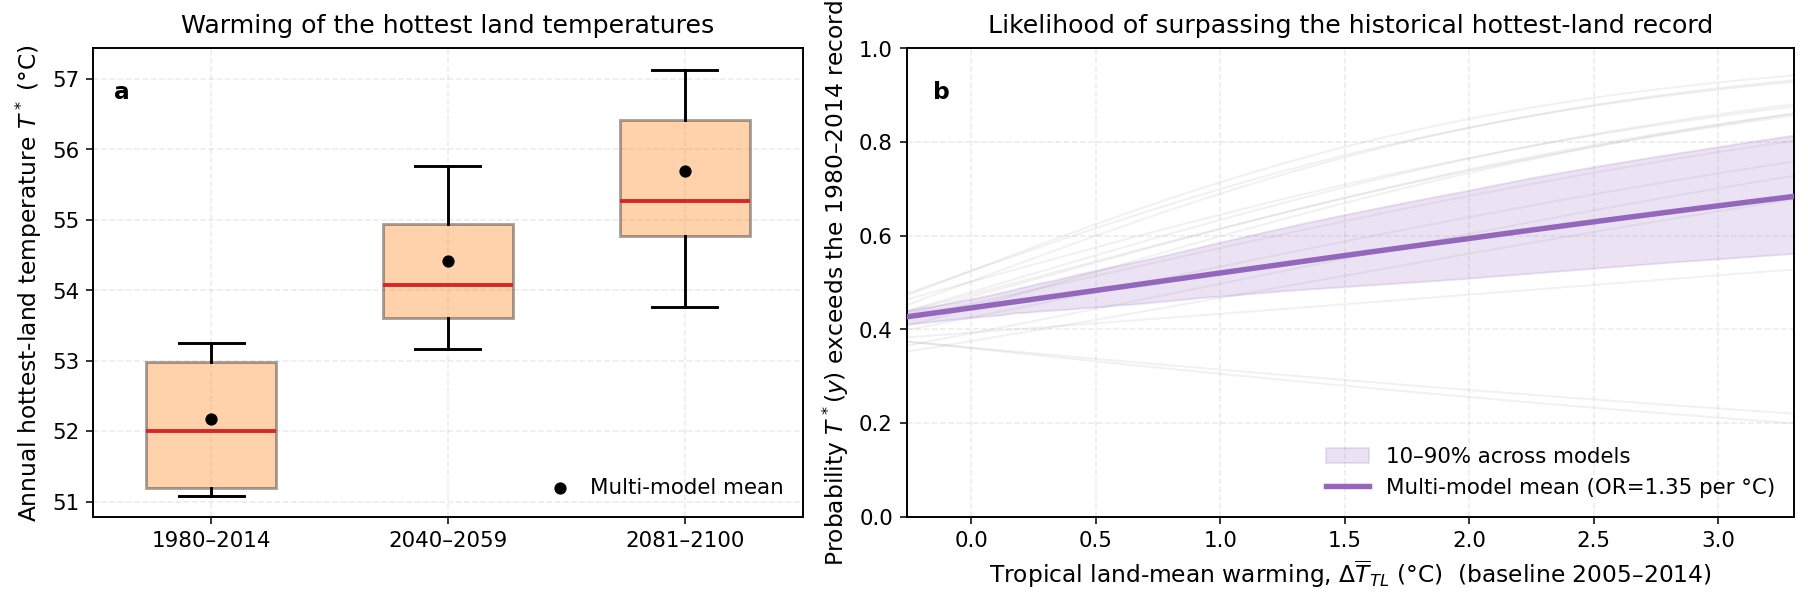

Saved: /content/drive/MyDrive/cmip6_extreme_hot_days/recordprob_fig2style_fixedThreshold/fig_recordprob_fixedThreshold_twoPanel_GRLclean.png and /content/drive/MyDrive/cmip6_extreme_hot_days/recordprob_fig2style_fixedThreshold/fig_recordprob_fixedThreshold_twoPanel_GRLclean.svg
Done.


In [ ]:
# ============================================================
# FIXED-THRESHOLD "RECORD EXCEEDANCE" PROBABILITY FIGURE (ROBUST TIME, GRL-CLEAN PLOTTING)
#
# Panel (a) boxplot: annual hottest-land temperature T*(y) by period across models
# Panel (b) logistic GLM: P(T*(y) > T*_record_hist) vs tropical land warming ΔT_TL(y)
#
# KEY CONSISTENCY CHOICES:
# - Predictor matches Fig 2: ΔT_TL relative to 2005–2014 (historical baseline)
# - T*(y): annual max of daily tasmax global land within LAT_BAND (default -45..45)
# - Event = FIXED historical-record exceedance:
#       record=1 if T*(y) > max_{1980–2014} T*(y)
#   (NOT running “new record” / ratcheting)
#
# ROBUSTNESS UPGRADES:
# - Force decoded times: open_zarr(decode_times=True, use_cftime=True)
# - Avoid fragile groupby("time.year"): create explicit year coord via years_from_time()
# - Avoid resample("1MS") in tas fallback path: annualize directly via explicit year coord
#
# GRL-CLEAN PLOTTING:
# - Climate-tailored titles
# - Legend band label: “10–90% across models” (less methods-y)
# - Spaghetti lines kept but quieter
# ============================================================

# !pip -q install xarray pandas regionmask gcsfs zarr fsspec statsmodels > /dev/null

from google.colab import drive
drive.mount("/content/drive")

import os, gc
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import regionmask
import statsmodels.api as sm

# ============================ USER SETTINGS ============================
OUTDIR = "/content/drive/MyDrive/cmip6_extreme_hot_days/recordprob_fig2style_fixedThreshold"
os.makedirs(OUTDIR, exist_ok=True)

# Predictor settings (match Fig 2)
REF_DTBAR = (2005, 2014)     # baseline for ΔT_TL anomaly
TROP_BAND = (-30, 30)        # tropical band for TL predictor

# Record metric settings
VAR_TASMAX       = "tasmax"
LAT_BAND         = (-45, 45) # land region for T* metric
WARM_SEASON_ONLY = False     # keep False unless you want a warm-season definition

# Record threshold window and fit/eval windows
HIST_RECORD_WINDOW = (1980, 2014)  # fixed record level = max over this window
FIT_WINDOW         = (2015, 2100)  # years used to fit GLM
EVAL_WINDOW        = (2026, 2100)  # expected # exceedance years summed here

# Model selection
ALLOWED = {
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-MM","UKESM1-0-LL"
}
EXCLUDE = {"NorESM2-LM", "TaiESM1"}

# Plot periods for panel (a)
PERIODS = [
    ("1980–2014", 1980, 2014),
    ("2040–2059", 2040, 2059),
    ("2081–2100", 2081, 2100),
]

# Fit stability controls
ALPHA_RIDGE_POOLED = 0.2
ALPHA_RIDGE_SPAGH  = 0.2
MIN_YEARS_FIT      = 25
MIN_RECORDS_SPAGH  = 3
MIN_NONREC_SPAGH   = 10

# Colors to match Fig 2 vibe
C_ORANGE = "tab:orange"
C_RED    = "tab:red"
C_PURPLE = "tab:purple"

# Figure style (similar to Fig 2)
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.5,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# ============================ CMIP6 CATALOG ============================
CMIP6_CSV = "https://storage.googleapis.com/cmip6/pangeo-cmip6.csv"
_cat = None

def catalog():
    global _cat
    if _cat is None:
        _cat = pd.read_csv(CMIP6_CSV)
    return _cat

# ============================ TIME HELPERS (robust) ============================
def years_from_time(time_coord):
    try:
        return time_coord.dt.year.values
    except Exception:
        pass
    try:
        return time_coord.to_index().year
    except Exception:
        pass
    try:
        return pd.to_datetime(np.asarray(time_coord.values)).year
    except Exception as e:
        raise RuntimeError(f"Could not extract years from time coord: {type(time_coord.values)}") from e

def months_from_time(time_coord):
    try:
        return time_coord.dt.month.values
    except Exception:
        pass
    try:
        return time_coord.to_index().month
    except Exception:
        pass
    try:
        return pd.to_datetime(np.asarray(time_coord.values)).month
    except Exception as e:
        raise RuntimeError(f"Could not extract months from time coord: {type(time_coord.values)}") from e

# ============================ DATA OPEN HELPERS ============================
def normalize_latlon(obj):
    if "latitude" in obj.coords:
        obj = obj.rename({"latitude": "lat"})
    if "longitude" in obj.coords:
        obj = obj.rename({"longitude": "lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180).sortby("lon")
    if "lat" in obj.coords and obj.lat.size > 1 and float(obj.lat[0]) > float(obj.lat[-1]):
        obj = obj.sortby("lat")
    return obj

def looks_like_kelvin(da):
    try:
        mx = float(da.max())
        mn = float(da.min())
        return (mx > 200) and (mn > 150)
    except Exception:
        v = da.isel({da.dims[0]: 0}).values
        return np.nanmax(v) > 200

def to_celsius(da):
    units = (da.attrs.get("units", "") or "").lower()
    if units in ["k", "kelvin"] or looks_like_kelvin(da):
        da = da - 273.15
        da.attrs["units"] = "degree_Celsius"
    return da

def pick_zstore(model, experiment, table_id, variable_id):
    df = catalog()
    sub = df[
        (df.source_id == model)
        & (df.experiment_id == experiment)
        & (df.table_id == table_id)
        & (df.variable_id == variable_id)
    ]
    if sub.empty:
        return None
    return sub.sort_values(["member_id", "grid_label"]).iloc[0].zstore

def open_zarr_da(zurl, var):
    ds = xr.open_zarr(
        zurl,
        consolidated=True,
        storage_options={"token": "anon"},
        chunks={},
        decode_times=True,
        use_cftime=True,
    )
    da = normalize_latlon(ds[var])
    if "time" in da.dims:
        da = da.sortby("time")
    return da

def open_daily_tasmax(model, experiment):
    zurl = pick_zstore(model, experiment, "day", VAR_TASMAX)
    if zurl is None:
        raise RuntimeError(f"No day/{VAR_TASMAX} for {model} {experiment}")
    return to_celsius(open_zarr_da(zurl, VAR_TASMAX))

def open_amon_tas_or_fallback(model, experiment):
    """
    Prefer Amon tas; fallback to daily tas (annualized later robustly).
    """
    zurl = pick_zstore(model, experiment, "Amon", "tas")
    if zurl is not None:
        return to_celsius(open_zarr_da(zurl, "tas"))

    zurl2 = pick_zstore(model, experiment, "day", "tas")
    if zurl2 is None:
        raise RuntimeError(f"No Amon tas and no day tas for {model} {experiment}")
    return to_celsius(open_zarr_da(zurl2, "tas"))

# ============================ MASKS & WEIGHTS (cached land mask) ============================
land_poly = regionmask.defined_regions.natural_earth_v5_0_0.land_110
_landmask_cache = {}

def area_weights(lat):
    w = np.cos(np.deg2rad(lat))
    return xr.DataArray(w / w.sum(), coords={"lat": lat}, dims=("lat",))

def land_mask_bool(lon, lat):
    key = (int(lat.size), int(lon.size),
           float(lat.values[0]), float(lat.values[-1]),
           float(lon.values[0]), float(lon.values[-1]))
    if key in _landmask_cache:
        return _landmask_cache[key]
    m = land_poly.mask(lon, lat).notnull()
    _landmask_cache[key] = m
    return m

def apply_land_and_band(da, lat_band):
    da = da.sel(lat=slice(*lat_band))
    m = land_mask_bool(da["lon"], da["lat"])
    return da.where(m)

def select_warm_season(da):
    if not WARM_SEASON_ONLY:
        return da
    months = months_from_time(da["time"])
    mm = xr.DataArray(months, coords={"time": da["time"]}, dims=("time",))

    da_nh = da.sel(lat=slice(max(0.0, LAT_BAND[0]), LAT_BAND[1]))
    if da_nh.lat.size > 0:
        da_nh = da_nh.sel(time=mm.isin([6, 7, 8]))

    da_sh = da.sel(lat=slice(LAT_BAND[0], min(0.0, LAT_BAND[1])))
    if da_sh.lat.size > 0:
        da_sh = da_sh.sel(time=mm.isin([12, 1, 2]))

    if da_nh.lat.size > 0 and da_sh.lat.size > 0:
        return xr.concat([da_sh, da_nh], dim="lat")
    elif da_nh.lat.size > 0:
        return da_nh
    else:
        return da_sh

# ============================ ΔT_TL: annual tropical-land mean tas anomaly ============================
def annual_TL_abs(model, experiment):
    """
    Annual tropical-land mean tas (absolute, °C).
    Robust annualization via explicit year coord (no time.year or resample).
    """
    tas = open_amon_tas_or_fallback(model, experiment)

    if "time" not in tas.dims:
        if "year" in tas.coords:
            df = pd.DataFrame({"year": tas["year"].values.astype(int),
                               "TL": np.asarray(tas.values, dtype=float)})
            return df.dropna().sort_values("year")
        raise RuntimeError(f"{model} {experiment}: tas has no usable time/year dimension")

    tas = tas.sortby("time")
    tas_tl = apply_land_and_band(tas, TROP_BAND)
    w = area_weights(tas_tl.lat)
    tl = tas_tl.weighted(w).mean(("lat", "lon"), skipna=True)

    yrs = years_from_time(tl["time"])
    tl = tl.assign_coords(year=("time", yrs))
    ann = tl.groupby("year").mean("time").compute()

    df = pd.DataFrame({"year": ann["year"].values.astype(int),
                       "TL": np.asarray(ann.values, dtype=float)})
    return df.dropna().sort_values("year")

def annual_dT_TL_histbaseline(model, ref_years=REF_DTBAR):
    Dh = annual_TL_abs(model, "historical")
    Ds = annual_TL_abs(model, "ssp245")
    Dall = pd.concat([Dh, Ds], axis=0).drop_duplicates("year").sort_values("year")

    refmask = (Dall["year"] >= ref_years[0]) & (Dall["year"] <= ref_years[1])
    if refmask.sum() == 0:
        raise RuntimeError(f"{model}: baseline {ref_years} not present in HIST+SSP TL series")

    ref = float(np.nanmean(Dall.loc[refmask, "TL"].values))
    Dall["dT_TL"] = Dall["TL"] - ref
    return Dall[["year", "dT_TL"]].dropna().sort_values("year")

# ============================ Annual hottest-land temperature T*(y) ============================
def annual_Tstar(model, experiment, time_chunk=365):
    """
    T*(y): annual max of daily global-land max tasmax within LAT_BAND and land mask.
    Robust annualization via explicit year coord.
    """
    da = open_daily_tasmax(model, experiment).chunk({"time": time_chunk})
    da = apply_land_and_band(da, LAT_BAND)
    da = select_warm_season(da)

    daily_max = da.max(("lat", "lon"), skipna=True)

    yrs = years_from_time(daily_max["time"])
    daily_max = daily_max.assign_coords(year=("time", yrs))

    Tstar = daily_max.groupby("year").max("time").compute()

    df = pd.DataFrame({"year": Tstar["year"].values.astype(int),
                       "Tstar": np.asarray(Tstar.values, dtype=float)})
    return df.dropna().sort_values("year")

# ============================ Fixed-threshold record exceedance ============================
def add_fixed_record_flag(df, init_window=HIST_RECORD_WINDOW, start_year=FIT_WINDOW[0]):
    """
    record_level = max Tstar over init_window (e.g., 1980–2014)
    record(y)=1 if year>=start_year and Tstar(y) > record_level.
    """
    df = df.sort_values("year").reset_index(drop=True)
    y0, y1 = init_window
    m0 = (df["year"] >= y0) & (df["year"] <= y1)
    if m0.sum() == 0:
        raise RuntimeError(f"no years in HIST_RECORD_WINDOW {init_window} after merge")

    record_level = float(df.loc[m0, "Tstar"].max())

    rec = []
    for y, t in zip(df["year"].values, df["Tstar"].values):
        if y < start_year:
            rec.append(0)
        else:
            rec.append(int(float(t) > record_level))

    df["record"] = rec
    df.attrs["fixed_record_level"] = record_level
    return df

def build_model_df(model):
    Th = annual_Tstar(model, "historical")
    Tf = annual_Tstar(model, "ssp245")
    Tdf = pd.concat([Th, Tf], axis=0).drop_duplicates("year").sort_values("year")

    Ddf = annual_dT_TL_histbaseline(model, ref_years=REF_DTBAR)

    df = pd.merge(Tdf, Ddf, on="year", how="inner").sort_values("year")
    df = add_fixed_record_flag(df, init_window=HIST_RECORD_WINDOW, start_year=FIT_WINDOW[0])

    df_fit = df[(df["year"] >= FIT_WINDOW[0]) & (df["year"] <= FIT_WINDOW[1])].copy()
    if df_fit.shape[0] < MIN_YEARS_FIT:
        raise RuntimeError(f"Too few years in fit window {FIT_WINDOW}: n={df_fit.shape[0]}")
    return df, df_fit

# ============================ Ridge logistic fit helpers ============================
def ridge_logit_fit(x, y, alpha=0.2):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    X = sm.add_constant(x, has_constant="add")
    model = sm.GLM(y, X, family=sm.families.Binomial())
    res = model.fit_regularized(alpha=alpha, L1_wt=0.0, maxiter=2000)
    return np.asarray(res.params, dtype=float)

def logit_predict(params, xgrid):
    xgrid = np.asarray(xgrid, dtype=float)
    Xg = sm.add_constant(xgrid, has_constant="add")
    eta = Xg @ params
    return 1.0 / (1.0 + np.exp(-eta))

# ============================ MODEL LIST ============================
def list_models_with_tasmax_and_tas_hist_ssp245():
    df = catalog()

    have_tasmax_day = df[(df.table_id == "day") & (df.variable_id == "tasmax")]
    hist_tmax = set(have_tasmax_day[have_tasmax_day.experiment_id == "historical"].source_id.unique())
    ssp_tmax  = set(have_tasmax_day[have_tasmax_day.experiment_id == "ssp245"].source_id.unique())
    ok_tmax = hist_tmax & ssp_tmax

    have_tas_amon = df[(df.table_id == "Amon") & (df.variable_id == "tas")]
    hist_tasA = set(have_tas_amon[have_tas_amon.experiment_id == "historical"].source_id.unique())
    ssp_tasA  = set(have_tas_amon[have_tas_amon.experiment_id == "ssp245"].source_id.unique())

    have_tas_day = df[(df.table_id == "day") & (df.variable_id == "tas")]
    hist_tasD = set(have_tas_day[have_tas_day.experiment_id == "historical"].source_id.unique())
    ssp_tasD  = set(have_tas_day[have_tas_day.experiment_id == "ssp245"].source_id.unique())

    ok_tas = (hist_tasA | hist_tasD) & (ssp_tasA | ssp_tasD)

    models = sorted(((ok_tmax & ok_tas) & set(ALLOWED)) - set(EXCLUDE))
    return models

# ============================ MAIN: build all model data ============================
MODELS_ALL = list_models_with_tasmax_and_tas_hist_ssp245()

print(f"Using {len(MODELS_ALL)} models with day tasmax + tas (Amon or day fallback) (hist+ssp245):")
print(MODELS_ALL)
print(f"Predictor matches Fig 2: tropical land mean tas anomaly rel. {REF_DTBAR}.")
print(f"Record definition: EXCEEDS fixed historical record (max over {HIST_RECORD_WINDOW}).")
print(f"Fit window: {FIT_WINDOW} | pooled ridge alpha={ALPHA_RIDGE_POOLED}")

per_model = {}
rows = []
record_levels = {}

for md in MODELS_ALL:
    try:
        df, df_fit = build_model_df(md)
        per_model[md] = (df, df_fit)
        record_levels[md] = float(df.attrs.get("fixed_record_level", np.nan))

        tmp = df_fit.copy()
        tmp["model"] = md
        rows.append(tmp)

        n1 = int(df_fit["record"].sum())
        n0 = int((df_fit["record"] == 0).sum())
        print(f"[ok data] {md:12s} years={df_fit.shape[0]:3d}  exceed={n1:2d}  nonexceed={n0:3d}  "
              f"T*_hist={record_levels[md]:.2f}°C")
    except Exception as e:
        print(f"[skip data] {md}: {e}")

if len(rows) == 0:
    raise RuntimeError("No models produced usable data. Check earlier skip reasons.")

pool = pd.concat(rows, axis=0).reset_index(drop=True)

# Save per-model fixed record thresholds (useful for SI)
levels_df = pd.DataFrame({
    "model": list(record_levels.keys()),
    "Tstar_record_hist_C": list(record_levels.values()),
}).sort_values("Tstar_record_hist_C")
levels_csv = os.path.join(OUTDIR, f"fixed_record_levels_hist{HIST_RECORD_WINDOW[0]}-{HIST_RECORD_WINDOW[1]}.csv")
levels_df.to_csv(levels_csv, index=False)
print(f"\nSaved fixed-threshold record levels: {levels_csv}")

# ============================ (A) Panel values: T* by period ============================
def collect_period_Tstar(per_model_dict, periods=PERIODS):
    out = {lab: [] for (lab, _, _) in periods}
    for _md, (df, _df_fit) in per_model_dict.items():
        for lab, y0, y1 in periods:
            m = (df["year"] >= y0) & (df["year"] <= y1)
            if m.sum() > 0:
                out[lab].append(float(df.loc[m, "Tstar"].mean()))
    return {k: np.array(v, dtype=float) for k, v in out.items()}

period_vals = collect_period_Tstar(per_model)

# ============================ (B) Logistic model: pooled MMM + optional spaghetti ============================
x_all = pool["dT_TL"].values
y_all = pool["record"].values

params_pool = ridge_logit_fit(x_all, y_all, alpha=ALPHA_RIDGE_POOLED)
OR_pool = float(np.exp(params_pool[1]))
print(f"\nPooled MMM ridge-logit: OR={OR_pool:.2f} per °C_TL  ({(OR_pool-1)*100:+.0f}% odds/°C_TL)")

# x-grid over central model ranges
xmins, xmaxs = [], []
for md, (_df, df_fit) in per_model.items():
    xmins.append(df_fit["dT_TL"].min())
    xmaxs.append(df_fit["dT_TL"].max())
x_lo = float(np.nanpercentile(xmins, 20))
x_hi = float(np.nanpercentile(xmaxs, 80))
xg = np.linspace(x_lo, x_hi, 300)

p_mmm = logit_predict(params_pool, xg)

def bootstrap_band(per_model_dict, xg, B=200, alpha=ALPHA_RIDGE_POOLED, qlo=10, qhi=90, seed=7):
    rng = np.random.default_rng(seed)
    models = list(per_model_dict.keys())
    preds = []
    for _ in range(B):
        samp = rng.choice(models, size=len(models), replace=True)
        parts = []
        for md in samp:
            df_fit = per_model_dict[md][1].copy()
            df_fit["model"] = md
            parts.append(df_fit)
        bb = pd.concat(parts, axis=0)
        try:
            params = ridge_logit_fit(bb["dT_TL"].values, bb["record"].values, alpha=alpha)
            preds.append(logit_predict(params, xg))
        except Exception:
            continue
    if len(preds) == 0:
        return np.full_like(xg, np.nan), np.full_like(xg, np.nan)
    P = np.vstack(preds)
    plo = np.nanpercentile(P, qlo, axis=0)
    phi = np.nanpercentile(P, qhi, axis=0)
    return plo, phi

plo, phi = bootstrap_band(per_model, xg, B=200, alpha=ALPHA_RIDGE_POOLED, qlo=10, qhi=90)

# Optional per-model spaghetti fits
spaghetti = []
OR_rows = []

for md, (_df, df_fit) in per_model.items():
    n1 = int(df_fit["record"].sum())
    n0 = int((df_fit["record"] == 0).sum())
    if (n1 < MIN_RECORDS_SPAGH) or (n0 < MIN_NONREC_SPAGH):
        continue
    try:
        params = ridge_logit_fit(df_fit["dT_TL"].values, df_fit["record"].values, alpha=ALPHA_RIDGE_SPAGH)
        spaghetti.append(logit_predict(params, xg))
        OR_rows.append({"model": md, "OR_per_degC_TL": float(np.exp(params[1])),
                        "n_exceed": n1, "n_years": df_fit.shape[0]})
    except Exception:
        continue

OR_df = pd.DataFrame(OR_rows).sort_values("OR_per_degC_TL", ascending=False)
OR_csv = os.path.join(OUTDIR, f"logit_OR_summary_fixedThreshold_fit{FIT_WINDOW[0]}-{FIT_WINDOW[1]}_alpha{ALPHA_RIDGE_POOLED}.csv")
OR_df.to_csv(OR_csv, index=False)
print(f"Saved OR table: {OR_csv}")
print(f"Spaghetti curves: {len(spaghetti)} models (min exceedances {MIN_RECORDS_SPAGH})")

# ============================ Expected # exceedance years (headline) ============================
E_exceed = {}
for md, (df, _df_fit) in per_model.items():
    m = (df["year"] >= EVAL_WINDOW[0]) & (df["year"] <= EVAL_WINDOW[1])
    if m.sum() == 0:
        continue
    p = logit_predict(params_pool, df.loc[m, "dT_TL"].values)
    E_exceed[md] = float(np.nansum(p))

E_series = pd.Series(E_exceed, name="E_exceed")
print(f"\nExpected # exceedance years (sum of annual probabilities) {EVAL_WINDOW[0]}–{EVAL_WINDOW[1]}:")
print(E_series.describe(percentiles=[0.1, 0.5, 0.9]))
print(f"MMM expected exceedance-years: {float(E_series.mean()):.2f}")

# ============================ PLOTTING (GRL-clean titles/legend) ============================
def plot_two_panel(period_vals, xg, p_mmm, plo, phi, spaghetti, outdir=OUTDIR):
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(12.8, 4.2),
        layout="constrained",
        gridspec_kw={"width_ratios": [1.0, 1.25]},
    )

    # ---- Panel (a): T* boxplot by period ----
    labels = [p[0] for p in PERIODS]
    data   = [period_vals[l] for l in labels]
    xpos   = np.arange(len(labels)) + 1

    bp = ax1.boxplot(
        data,
        positions=xpos,
        widths=0.55,
        whis=(10, 90),
        showfliers=False,
        patch_artist=True,
        medianprops={"linewidth": 2.0, "color": C_RED},
        whiskerprops={"linewidth": 1.5},
        capprops={"linewidth": 1.5},
        boxprops={"linewidth": 1.5},
    )
    for b in bp["boxes"]:
        b.set_facecolor(C_ORANGE)
        b.set_alpha(0.35)

    means = [np.nanmean(d) for d in data]
    ax1.scatter(xpos, means, color="k", s=28, zorder=3, label="Multi-model mean")

    ax1.set_xticks(xpos, labels)
    ax1.set_ylabel(r"Annual hottest-land temperature $T^*$ (°C)")
    ax1.set_title("Warming of the hottest land temperatures", pad=8)
    ax1.grid(axis="y", alpha=0.25)
    ax1.legend(frameon=False, loc="lower right", handlelength=1.2)
    ax1.text(0.03, 0.93, "a", transform=ax1.transAxes, fontweight="bold", ha="left", va="top")

    # ---- Panel (b): exceedance probability vs warming ----
    # Keep spaghetti but quieter
    for s in spaghetti:
        ax2.plot(xg, s, color="0.55", alpha=0.12, lw=1.0, zorder=1)

    ax2.fill_between(
        xg, plo, phi,
        color=C_PURPLE, alpha=0.18,
        label="10–90% across models",
        zorder=2,
    )

    ax2.plot(
        xg, p_mmm,
        color=C_PURPLE, lw=2.8,
        label=f"Multi-model mean (OR={float(np.exp(params_pool[1])):.2f} per °C)",
        zorder=3,
    )

    ax2.set_xlabel(r"Tropical land-mean warming, $\Delta \overline{T}_{TL}$ (°C)  (baseline 2005–2014)")
    ax2.set_ylabel(r"Probability $T^*(y)$ exceeds the 1980–2014 record")
    ax2.set_ylim(0, 1)
    ax2.set_xlim(xg.min(), xg.max())
    ax2.set_title("Likelihood of surpassing the historical hottest-land record", pad=8)
    ax2.legend(frameon=False, loc="lower right")
    ax2.text(0.03, 0.93, "b", transform=ax2.transAxes, fontweight="bold", ha="left", va="top")

    ax2.yaxis.set_major_locator(MultipleLocator(0.2))

    for ax in (ax1, ax2):
        for sp in ax.spines.values():
            sp.set_linewidth(1.0)

    png = os.path.join(outdir, "fig_recordprob_fixedThreshold_twoPanel_GRLclean.png")
    svg = os.path.join(outdir, "fig_recordprob_fixedThreshold_twoPanel_GRLclean.svg")
    fig.savefig(png, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(svg, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("Saved:", png, "and", svg)

plot_two_panel(period_vals, xg, p_mmm, plo, phi, spaghetti, outdir=OUTDIR)

plt.close("all")
gc.collect()
print("Done.")
